
A. Preparación del Estado (Principio)
Sirven para inicializar tu sistema cuántico antes de aplicar compuertas. Por defecto, todos los qubits empiezan en el estado 

∣0⟩
.
qml.BasisState: Prepara estados clásicos binarios (ej. 
∣
101
⟩
∣101⟩
).
qml.StatePrep (antes QubitStateVector): Prepara un estado cuántico arbitrario dando sus amplitudes.
B. Compuertas / Gates (El Medio)
Son las operaciones que modifican el estado de los qubits.
No parametrizadas: No tienen variables a optimizar.
qml.Hadamard: Crea superposición.
qml.PauliX, qml.PauliY, qml.PauliZ: Rotaciones fijas de 180 grados (PauliX equivale a la compuerta NOT clásica).
qml.CNOT: Compuerta condicional de 2 qubits, fundamental para el entrelazamiento.
Parametrizadas: Reciben un valor (como un ángulo) que el Machine Learning va a optimizar.
qml.RX, qml.RY, qml.RZ: Rotaciones en los ejes de la esfera de Bloch.
qml.CRX, qml.CRY, qml.CRZ: Rotaciones controladas por otro qubit.
C. Mediciones y Observables (El Final)
Para sacar información del mundo cuántico al clásico, DEBES terminar tu circuito con una función de medición matemática, la cual mide una propiedad física (Observable).
Mediciones: qml.expval() (Valor esperado/promedio), qml.var() (Varianza), qml.probs() (Probabilidades), qml.sample() (Muestreo uno a uno).
Observables: Lo que pones dentro de la medición. qml.PauliZ, qml.PauliX o combinaciones tensoriales de ellos usando el operador @.

# State preparation

By default all qubits in ∣0⟩

    -   qml.BasisState: give a binary state ( ∣101⟩ )
    -   qml.StatePrep: give amplitudes

# Gates

No parametrized

    -   qml.Hadamard
    -   qml.PauliX, qml.PauliY, qml.PauliZ
    -   qml.CNOT

Parametrized

    -   qml.RX, qml.RY, qml.RZ
    -   qml.CRX, qml.CRY, qml.CRZ

# Measurements and Observables

Measurements: 

    - qml.expval()   (average)
    - qml.var()   (variance)
    - qml.probs()   (probabilities)
    - qml.sample()   (individual sample)

Observables:

    - qml.PauliZ
    - qml.PauliX
    - tensorial combinations with @

In [3]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

dev = qml.device("default.qubit", wires=3)

@qml.qnode(dev)
def circuit(angles):

    # State Preparation
    qml.BasisState(np.array([1, 1]), wires=[0, 1]) # Qubit 0 and 1 in |11> instead of |00>
    
    # No parametrized Gates
    qml.Hadamard(wires=2) # Hadamard qubit 2 (|0> + |1>)
    qml.PauliX(wires=0) # PauliX al qubit 0 (|0>)
    

    # Parametrized Gates
    qml.RY(angles[0], wires=1) # Rotate qubit 1
    qml.RX(angles[1], wires=2) # Rotate qubit 2
    
    # Entanglement qubit 1 & 2
    qml.CNOT(wires=[1, 2])
    
    # Measurements and Observables (can return multiple measurements at the same time)
    return[
        # Measure in Z, q0
        qml.expval(qml.PauliZ(0)),
        
        # Probabilities of collapse, q1 & q2 
        qml.probs(wires=[1, 2]),
        
        # Tensorial Product (X in q1 & Y in q2 simultaneously)
        qml.expval(qml.PauliX(1) @ qml.PauliY(2))
    ]

# Angles
angles = np.array([0.5, 1.2])

# Execute
results = circuit(angles)

# Print Results
print(f"Measure Z q0: {results[0]:.4f}")
print(f"Probabs of q1 & q2: {results[1]}")
print(f"Tensorial product X q1 & Y q2: {results[2]:.4f}")

Measure Z q0: 1.0000
Probabs of q1 & q2: [0.03060436 0.03060436 0.46939564 0.46939564]
Tensorial product X q1 & Y q2: 0.0000


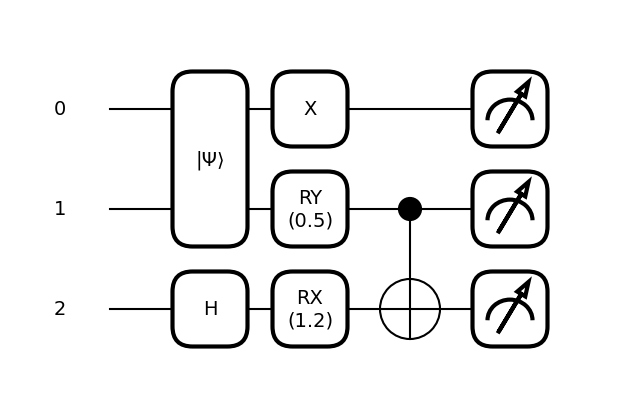

In [4]:
#Show Circuit
qnode = qml.QNode(circuit, dev)
qml.draw_mpl(qnode, decimals=1, style="black_white")(angles)
plt.show()

In [11]:
# Device with a limited number of executions (shots)
dev_shots = qml.device("default.qubit", wires=2, shots=100)

@qml.qnode(dev_shots)
def measurement_circuit(angle):
    # q0 in superposition
    qml.Hadamard(wires=0)
    
    # Rotate q1 
    qml.RX(angle, wires=1)
    
    # Entangle both qubits
    qml.CNOT(wires=[0, 1])
    
    # Return different types of measurements at the same time
    return[
        qml.sample(wires=0),         # Raw outputs for qubit 0
        qml.counts(wires=[0, 1]),    # Histogram of states for both qubits
        qml.var(qml.PauliZ(1))       # Variance of PauliZ on qubit 1
    ]

# Execute the circuit
angle_val = 0.5
results = measurement_circuit(angle_val)

samples, counts, variance = results

print("--- RAW SAMPLES (First 10 shots of qubit 0) ---")
# Output = array of 100 elements
print(samples[:10]) 

print("\n--- MEASUREMENT COUNTS (Histogram) ---")
print(counts)

print("\n--- VARIANCE ---")
# Statistical variance of the PauliZ observable
print(f"Variance of PauliZ(1): {variance:.4f}")

--- RAW SAMPLES (First 10 shots of qubit 0) ---
[[0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]]

--- MEASUREMENT COUNTS (Histogram) ---
{np.str_('00'): np.int64(38), np.str_('01'): np.int64(2), np.str_('10'): np.int64(3), np.str_('11'): np.int64(57)}

--- VARIANCE ---
Variance of PauliZ(1): 0.9804
